# Bump Plot

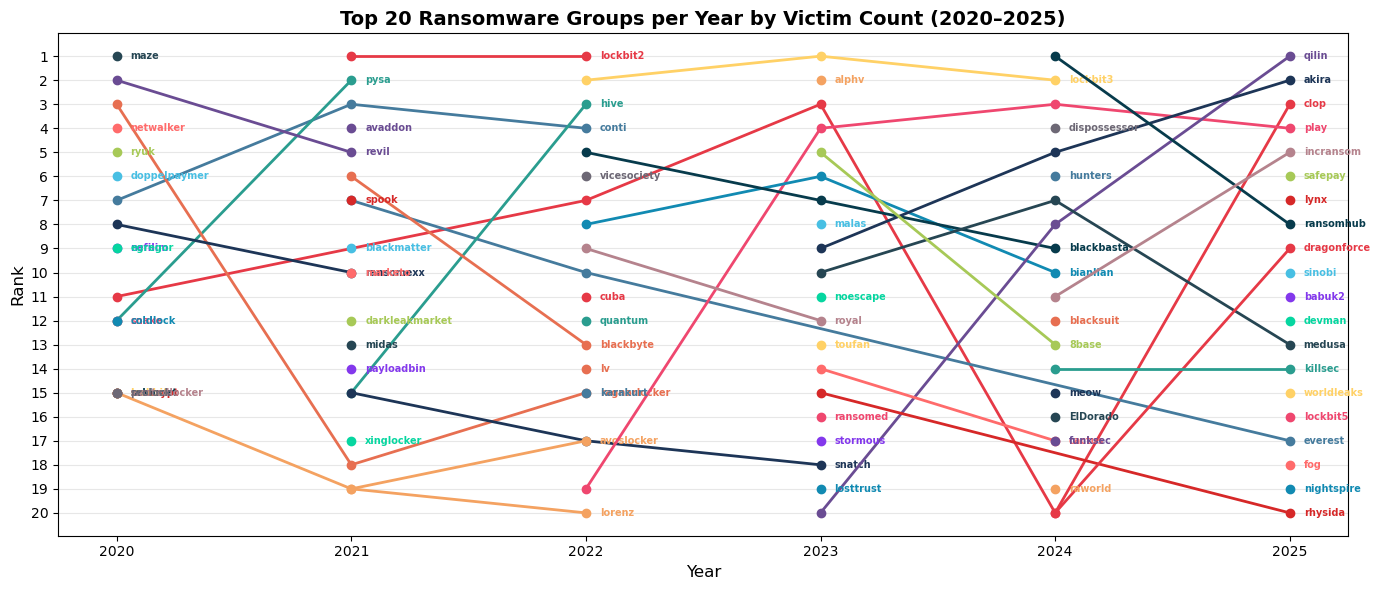

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv('output/groups_activity_by_year.csv')
years = [str(y) for y in range(2020, 2026)]

long = df.melt(id_vars='group_name', value_vars=years, var_name='year', value_name='victims')
long['year'] = long['year'].astype(int)

# rank per year, keep only top 20 each year
records = []
for yr, g in long.groupby('year'):
    active = g[g['victims'] > 0].copy()
    active['rank'] = active['victims'].rank(ascending=False, method='min').astype(int)
    records.append(active[active['rank'] <= 20])
ranked = pd.concat(records)

all_groups = ranked['group_name'].unique().tolist()

palette = [
    '#e63946', '#457b9d', '#2a9d8f', '#e76f51', '#6a4c93',
    '#1d3557', '#f4a261', '#264653', '#a7c957', '#d62828',
    '#ff6b6b', '#48bfe3', '#8338ec', '#06d6a0', '#ffd166',
    '#ef476f', '#118ab2', '#073b4c', '#b5838d', '#6d6875'
]
colors = {g: palette[i % len(palette)] for i, g in enumerate(all_groups)}

fig, ax = plt.subplots(figsize=(14, 6))

for group in all_groups:
    gd = ranked[ranked['group_name'] == group].sort_values('year')
    ax.plot(
        gd['year'], gd['rank'], '-o',
        color=colors[group], linewidth=2.0,
        markersize=6, label=group, zorder=3
    )
    last = gd.iloc[-1]
    ax.annotate(
        group, (last['year'], last['rank']),
        textcoords='offset points',
        xytext=(10, 0), fontsize=7,
        color=colors[group], fontweight='bold', va='center'
    )

ax.invert_yaxis()
ax.set_yticks(range(1, 21))
ax.set_xticks(range(2020, 2026))
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Rank', fontsize=12)
ax.set_title('Top 20 Ransomware Groups per Year by Victim Count (2020–2025)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
# ax.legend(loc='upper left', fontsize=7, ncol=3, bbox_to_anchor=(0, -0.08))

plt.tight_layout()
plt.savefig('bump_chart.png', dpi=200, bbox_inches='tight')
plt.show()